# Simulated Annealing for Optimal Epsilon Search — PTB-XL DP-SGD

**Bachelor Thesis — Differential Privacy for Medical Data**

This notebook uses **Simulated Annealing (SA)** to find the optimal privacy budget epsilon (ε) for DP-SGD training on the PTB-XL ECG dataset, using the same **composite fitness function** (0.7 × AUROC + 0.3 × privacy score) applied to the Genetic Algorithm, Bayesian Optimisation, and PSO notebooks.

### What makes SA different
SA is the only **single-solution, probabilistic acceptance** method in this thesis. Unlike GA and PSO (which maintain a population) or BO (which builds a surrogate model), SA maintains a single current solution and explores by proposing random perturbations. The key innovation is that it accepts worse solutions with a probability that decreases over time — allowing it to escape local optima early in the search and converge precisely later.

| Method | Paradigm | Population? | Accepts worse moves? |
|---|---|---|---|
| Genetic Algorithm | Evolutionary | Yes | No (only selection pressure) |
| Bayesian Optimisation (TPE) | Surrogate model | No | Via acquisition function |
| Particle Swarm (PSO) | Swarm intelligence | Yes | No (only velocity) |
| NSGA-II | Multi-objective evolutionary | Yes | No |
| Epsilon-Constraint | Constraint sweep | No | N/A |
| **Simulated Annealing** | **Probabilistic metaheuristic** | **No** | **Yes — explicitly** |

### How SA works
The algorithm is inspired by the physical annealing of metals: at high temperature, atoms move freely; as temperature drops, they settle into a stable low-energy configuration.

At each iteration:
1. Propose a neighbour: `ε_new = ε_current + N(0, σ)`, clamped to [EPS_MIN, EPS_MAX]
2. Evaluate composite fitness at `ε_new`
3. Compute `ΔF = fitness(ε_new) − fitness(ε_current)`
4. If `ΔF > 0` (improvement) → always accept
5. If `ΔF ≤ 0` (worse) → accept with probability `exp(ΔF / T)`
6. Cool the temperature: `T = T × α`

Early iterations (high T): `exp(ΔF/T)` is close to 1 → almost always accept → wide exploration  
Late iterations (low T): `exp(ΔF/T)` approaches 0 → rarely accept worse → precise exploitation

### Reference
Kirkpatrick, S., Gelatt, C.D., Vecchi, M.P. (1983). Optimisation by Simulated Annealing. *Science*, 220(4598), 671–680. (50,000+ citations)

## Cell 1 — Install Dependencies

In [1]:
!pip install opacus==1.4.0 wfdb --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 224.8/224.8 kB 4.5 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 4.3 MB/s eta 0:00:00:00:01


## Cell 2 — Imports & Configuration

In [2]:
import os
import gc
import math
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision.models as models

from sklearn.metrics import roc_auc_score

import wfdb

from opacus import PrivacyEngine
from opacus.utils.batch_memory_manager import BatchMemoryManager

warnings.filterwarnings('ignore')

# ─── PATHS ────────────────────────────────────────────────────────────────────
DATA_PATH   = "/kaggle/input/datasets/khyeh0719/ptb-xl-dataset/ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.1"
RESULTS_DIR = "/kaggle/working/sa_results"
os.makedirs(RESULTS_DIR, exist_ok=True)

# ─── MODEL / TRAINING SETTINGS ───────────────────────────────────────────────
DELTA         = 1e-5
MAX_GRAD_NORM = 1.0
EPOCHS        = 3
BATCH_SIZE    = 32
MAX_PHY_BATCH = 32
LR            = 1e-3
N_CLASSES     = 5
SEED          = 42

# ─── COMPOSITE FITNESS SETTINGS ──────────────────────────────────────────────
PRIVACY_WEIGHT = 0.3    # 30% weight on privacy, 70% on AUROC
EPS_MIN        = 0.5    # lower bound for epsilon search
EPS_MAX        = 20.0   # upper bound for epsilon search

# ─── SIMULATED ANNEALING SETTINGS ────────────────────────────────────────────
T_START      = 0.50     # initial temperature (on the scale of fitness differences)
T_END        = 0.001    # final temperature (near zero = pure exploitation)
ALPHA        = 0.85     # geometric cooling rate: T = T * ALPHA each iteration
SIGMA        = 3.0      # std dev of Gaussian perturbation for neighbour proposal
N_ITERATIONS = 15       # number of SA steps (total evals = N_ITERATIONS + 1)

# ─── COMPARISON VALUES FROM PREVIOUS EXPERIMENTS ─────────────────────────────
KNEEDLE_EPS    = 5.0
KNEEDLE_AUROC  = 0.8777
GA_EPS         = 1.110
GA_AUROC       = 0.8698
BO_EPS         = 0.8056
BO_AUROC       = 0.8271
PSO_EPS        = 1.2035
PSO_AUROC      = 0.8329
NSGA2_EPS      = 8.9853
NSGA2_AUROC    = 0.8548
BASELINE_AUROC = 0.9318

torch.manual_seed(SEED)
np.random.seed(SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Print cooling schedule
temps = [T_START * (ALPHA ** i) for i in range(N_ITERATIONS + 1)]
print(f"Device         : {DEVICE}")
print(f"SA config      : {N_ITERATIONS} iterations | T: {T_START} -> {temps[-1]:.4f} | alpha={ALPHA}")
print(f"Sigma          : {SIGMA} (Gaussian perturbation std dev)")
print(f"Epsilon range  : [{EPS_MIN}, {EPS_MAX}]")
print(f"Total evals    : {N_ITERATIONS + 1} max (fewer if cache hits)")
print(f"Fitness formula: {1-PRIVACY_WEIGHT}*AUROC + {PRIVACY_WEIGHT}*privacy_score")
print(f"\nCooling schedule preview:")
for i in [0, 3, 6, 9, 12, N_ITERATIONS]:
    t = T_START * (ALPHA ** i)
    prob_example = math.exp(-0.05 / t) if t > 0 else 0
    print(f"  Iter {i:2d}: T={t:.4f}  P(accept ΔF=-0.05) = {prob_example:.3f}")

Device         : cuda
SA config      : 15 iterations | T: 0.5 -> 0.0437 | alpha=0.85
Sigma          : 3.0 (Gaussian perturbation std dev)
Epsilon range  : [0.5, 20.0]
Total evals    : 16 max (fewer if cache hits)
Fitness formula: 0.7*AUROC + 0.3*privacy_score

Cooling schedule preview:
  Iter  0: T=0.5000  P(accept ΔF=-0.05) = 0.905
  Iter  3: T=0.3071  P(accept ΔF=-0.05) = 0.850
  Iter  6: T=0.1886  P(accept ΔF=-0.05) = 0.767
  Iter  9: T=0.1158  P(accept ΔF=-0.05) = 0.649
  Iter 12: T=0.0711  P(accept ΔF=-0.05) = 0.495
  Iter 15: T=0.0437  P(accept ΔF=-0.05) = 0.318


## Cell 3 — Load PTB-XL Metadata

In [3]:
import ast

ptbxl_db  = pd.read_csv(os.path.join(DATA_PATH, 'ptbxl_database.csv'), index_col='ecg_id')
scp_codes = pd.read_csv(os.path.join(DATA_PATH, 'scp_statements.csv'), index_col=0)
ptbxl_db['scp_codes'] = ptbxl_db['scp_codes'].apply(ast.literal_eval)
scp_codes = scp_codes[scp_codes['diagnostic'] == 1.0]

SUPERCLASSES = ['NORM', 'MI', 'STTC', 'CD', 'HYP']

def get_superclass_labels(scp_dict):
    labels = np.zeros(N_CLASSES, dtype=np.float32)
    for code, likelihood in scp_dict.items():
        if code in scp_codes.index:
            superclass = scp_codes.loc[code, 'diagnostic_class']
            if superclass in SUPERCLASSES and likelihood >= 50:
                labels[SUPERCLASSES.index(superclass)] = 1.0
    return labels

ptbxl_db['labels'] = ptbxl_db['scp_codes'].apply(get_superclass_labels)
ptbxl_db = ptbxl_db[ptbxl_db['labels'].apply(lambda x: x.sum() > 0)]

train_df = ptbxl_db[ptbxl_db['strat_fold'] <= 8].reset_index(drop=True)
val_df   = ptbxl_db[ptbxl_db['strat_fold'] == 9].reset_index(drop=True)
test_df  = ptbxl_db[ptbxl_db['strat_fold'] == 10].reset_index(drop=True)
print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")

Train: 16315 | Val: 2043 | Test: 2055


## Cell 4 — Shared Utilities (Dataset, Model, Evaluate)

In [4]:
class ECGDataset(Dataset):
    def __init__(self, df, data_root, sampling_freq=100):
        self.df = df.reset_index(drop=True)
        self.data_root = data_root
        self.freq_col  = 'filename_lr' if sampling_freq == 100 else 'filename_hr'

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row    = self.df.iloc[idx]
        fpath  = os.path.join(self.data_root, row[self.freq_col])
        record = wfdb.rdrecord(fpath)
        signal = record.p_signal.T.astype(np.float32)   # (12, 1000)
        signal = (signal - signal.mean()) / (signal.std() + 1e-8)
        label  = torch.tensor(row['labels'], dtype=torch.float32)
        return torch.tensor(signal), label


def build_model():
    model = models.resnet18(weights=None)
    model.conv1 = nn.Conv2d(1, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    model.bn1   = nn.GroupNorm(32, 64)

    def replace_bn(module):
        for name, child in module.named_children():
            if isinstance(child, nn.BatchNorm2d):
                setattr(module, name, nn.GroupNorm(min(32, child.num_features), child.num_features))
            else:
                replace_bn(child)
    replace_bn(model)

    in_features = model.fc.in_features
    model.fc    = nn.Linear(in_features, N_CLASSES)
    return model


def make_loaders(train_df, val_df, test_df, data_path, batch_size):
    train_ds = ECGDataset(train_df, data_path)
    val_ds   = ECGDataset(val_df,   data_path)
    test_ds  = ECGDataset(test_df,  data_path)

    def collate(batch):
        signals, labels = zip(*batch)
        return torch.stack(signals).unsqueeze(1), torch.stack(labels)

    return (
        DataLoader(train_ds, batch_size=batch_size, shuffle=True,  collate_fn=collate, num_workers=2, drop_last=True),
        DataLoader(val_ds,   batch_size=batch_size, shuffle=False, collate_fn=collate, num_workers=2),
        DataLoader(test_ds,  batch_size=batch_size, shuffle=False, collate_fn=collate, num_workers=2),
    )


def evaluate(model, loader, criterion, device):
    model.eval()
    all_labels, all_probs, total_loss = [], [], 0.0
    with torch.no_grad():
        for x, y in loader:
            x, y   = x.to(device), y.to(device)
            logits  = model(x)
            total_loss += criterion(logits, y).item()
            all_probs.append(torch.sigmoid(logits).cpu().numpy())
            all_labels.append(y.cpu().numpy())
    probs  = np.vstack(all_probs)
    labels = np.vstack(all_labels)
    auroc_macro = roc_auc_score(labels, probs, average='macro')
    auroc_micro = roc_auc_score(labels, probs, average='micro')
    return total_loss / len(loader), auroc_macro, auroc_micro

print("Utilities ready.")

Utilities ready.


## Cell 5 — SA Fitness Function

The fitness function trains DP-SGD at a given epsilon and returns the **composite score**:

```
privacy_score   = 1 - (epsilon / EPS_MAX)
composite_score = (1 - PRIVACY_WEIGHT) * AUROC + PRIVACY_WEIGHT * privacy_score
```

A cache avoids re-training at epsilon values already evaluated (rounded to 2 decimal places).

In [5]:
eval_log      = []   # {iteration, epsilon, auroc, fitness, privacy_score, accepted, cached}
fitness_cache = {}   # key: round(epsilon, 2)

def evaluate_epsilon(epsilon, iteration, accepted=True):
    """
    Train DP-SGD at given epsilon, return composite fitness.
    Results cached by round(epsilon, 2) to avoid redundant training.
    """
    eps_key = round(epsilon, 2)

    if eps_key in fitness_cache:
        cached = fitness_cache[eps_key]
        print(f"    [cache] eps={epsilon:.4f} -> AUROC={cached['auroc']:.4f} | Fitness={cached['fitness']:.4f}")
        eval_log.append({
            'iteration': iteration, 'epsilon': epsilon,
            'auroc': cached['auroc'], 'fitness': cached['fitness'],
            'privacy_score': cached['privacy_score'],
            'accepted': accepted, 'cached': True
        })
        return cached['fitness']

    torch.cuda.empty_cache()
    gc.collect()

    train_loader, val_loader, _ = make_loaders(train_df, val_df, test_df, DATA_PATH, BATCH_SIZE)
    model     = build_model().to(DEVICE)
    criterion = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=LR)

    privacy_engine = PrivacyEngine(accountant='rdp')
    model, optimizer, train_loader = privacy_engine.make_private_with_epsilon(
        module=model, optimizer=optimizer, data_loader=train_loader,
        target_epsilon=epsilon, target_delta=DELTA,
        epochs=EPOCHS, max_grad_norm=MAX_GRAD_NORM,
    )

    for epoch in range(1, EPOCHS + 1):
        model.train()
        with BatchMemoryManager(data_loader=train_loader,
                                max_physical_batch_size=MAX_PHY_BATCH,
                                optimizer=optimizer) as safe_loader:
            for x, y in safe_loader:
                x, y = x.to(DEVICE), y.to(DEVICE)
                optimizer.zero_grad()
                criterion(model(x), y).backward()
                optimizer.step()
        achieved_eps = privacy_engine.get_epsilon(DELTA)
        _, _, val_auroc = evaluate(model, val_loader, criterion, DEVICE)
        print(f"      Epoch {epoch}/{EPOCHS} | AUROC micro: {val_auroc:.4f} | eps achieved: {achieved_eps:.3f}")

    _, _, final_auroc = evaluate(model, val_loader, criterion, DEVICE)

    privacy_score   = 1.0 - (epsilon / EPS_MAX)
    composite_score = (1 - PRIVACY_WEIGHT) * final_auroc + PRIVACY_WEIGHT * privacy_score

    print(f"    -> eps={epsilon:.4f} | AUROC={final_auroc:.4f} | Privacy={privacy_score:.4f} | Fitness={composite_score:.4f}")

    fitness_cache[eps_key] = {
        'auroc': final_auroc, 'fitness': composite_score, 'privacy_score': privacy_score
    }
    eval_log.append({
        'iteration': iteration, 'epsilon': epsilon,
        'auroc': final_auroc, 'fitness': composite_score,
        'privacy_score': privacy_score,
        'accepted': accepted, 'cached': False
    })

    del model, optimizer, privacy_engine
    torch.cuda.empty_cache()
    gc.collect()

    return composite_score


print("Fitness function ready.")
print(f"  Composite formula: {1-PRIVACY_WEIGHT}*AUROC + {PRIVACY_WEIGHT}*privacy_score")
print(f"  Cache enabled — rounded to 2 decimal places")

Fitness function ready.
  Composite formula: 0.7*AUROC + 0.3*privacy_score
  Cache enabled — rounded to 2 decimal places


## Cell 6 — Run Simulated Annealing

> **Expected time:** ~16 evaluations × ~12 min each ≈ **~3 hours** on T4×1 (cache can reduce this if revisiting similar epsilon values)

### SA update logic
At each iteration:
- Propose: `ε_new = clip(ε_current + N(0, σ), EPS_MIN, EPS_MAX)`
- If `ΔF > 0` (better) → accept
- If `ΔF ≤ 0` (worse) → accept with probability `exp(ΔF / T)`
- Cool: `T = T × α`

In [6]:
print("Starting Simulated Annealing for Optimal Epsilon Search")
print("="*60)
print(f"Iterations   : {N_ITERATIONS} (+ 1 init = {N_ITERATIONS + 1} max evals)")
print(f"Temperature  : {T_START} -> ~{T_START * ALPHA**N_ITERATIONS:.4f} (alpha={ALPHA})")
print(f"Sigma        : {SIGMA}")
print(f"Epsilon range: [{EPS_MIN}, {EPS_MAX}]")
print(f"Objective    : composite fitness ({int((1-PRIVACY_WEIGHT)*100)}% AUROC + {int(PRIVACY_WEIGHT*100)}% privacy)")
print("="*60)

np.random.seed(SEED)

# ─── Initialisation ───────────────────────────────────────────────────────────
# Log-uniform initialisation gives fair probability to small epsilon values
eps_current = float(np.exp(np.random.uniform(np.log(EPS_MIN), np.log(EPS_MAX))))
print(f"\nIteration 0 (initialisation) | eps = {eps_current:.4f}")
fit_current = evaluate_epsilon(eps_current, iteration=0)

# Track the best solution found overall
best_eps     = eps_current
best_fitness = fit_current

T = T_START
n_accepted  = 0
n_rejected  = 0
n_uphill    = 0   # accepted despite being worse (SA-specific behaviour)

print(f"\nInitial solution: eps={eps_current:.4f} | Fitness={fit_current:.4f}")
print(f"Initial temperature: T={T:.4f}")

# ─── SA main loop ─────────────────────────────────────────────────────────────
for it in range(1, N_ITERATIONS + 1):
    print(f"\nIteration {it}/{N_ITERATIONS} | T={T:.4f} | current eps={eps_current:.4f} | current fit={fit_current:.4f}")

    # Propose neighbour: Gaussian perturbation, clamped to valid range
    eps_new = float(np.clip(eps_current + np.random.normal(0, SIGMA), EPS_MIN, EPS_MAX))
    print(f"  Proposed eps_new = {eps_new:.4f}  (perturbation = {eps_new - eps_current:+.4f})")

    fit_new = evaluate_epsilon(eps_new, iteration=it)

    delta_f = fit_new - fit_current

    if delta_f > 0:
        # Improvement — always accept
        accept = True
        print(f"  => ACCEPTED (improvement: ΔF={delta_f:+.4f})")
        n_accepted += 1
    else:
        # Worse — accept with probability exp(ΔF / T)
        prob = math.exp(delta_f / T)
        rand = np.random.random()
        accept = rand < prob
        if accept:
            print(f"  => ACCEPTED (uphill: ΔF={delta_f:+.4f} | P={prob:.4f} | rand={rand:.4f}) [SA exploration]")
            n_uphill += 1
            n_accepted += 1
        else:
            print(f"  => REJECTED (ΔF={delta_f:+.4f} | P={prob:.4f} | rand={rand:.4f})")
            n_rejected += 1

    if accept:
        eps_current = eps_new
        fit_current = fit_new

    # Update eval_log with accept/reject decision
    eval_log[-1]['accepted'] = accept

    # Track global best
    if fit_new > best_fitness:
        best_fitness = fit_new
        best_eps     = eps_new
        print(f"  ** New global best: eps={best_eps:.4f} | Fitness={best_fitness:.4f}")

    # Geometric cooling
    T *= ALPHA

# ─── Final result ─────────────────────────────────────────────────────────────
best_cache   = fitness_cache[round(best_eps, 2)]
best_auroc   = best_cache['auroc']
best_privacy = best_cache['privacy_score']

n_unique = sum(1 for e in eval_log if not e['cached'])
n_cached = sum(1 for e in eval_log if e['cached'])

print(f"\n{'='*60}")
print(f" SIMULATED ANNEALING COMPLETE")
print(f" OPTIMAL EPSILON (SA): eps = {best_eps:.4f}")
print(f" Composite fitness   : {best_fitness:.4f}")
print(f" AUROC at optimal eps: {best_auroc:.4f}")
print(f" Privacy score       : {best_privacy:.4f}")
print(f" Total evaluations   : {len(eval_log)} ({n_unique} unique, {n_cached} cached)")
print(f" Accepted moves      : {n_accepted} (of which {n_uphill} were uphill/exploratory)")
print(f" Rejected moves      : {n_rejected}")
print(f"{'='*60}")

Starting Simulated Annealing for Optimal Epsilon Search
Iterations   : 15 (+ 1 init = 16 max evals)
Temperature  : 0.5 -> ~0.0437 (alpha=0.85)
Sigma        : 3.0
Epsilon range: [0.5, 20.0]
Objective    : composite fitness (70% AUROC + 30% privacy)

Iteration 0 (initialisation) | eps = 1.9907


04/14/2026 12:09:01:WARNING:Ignoring drop_last as it is not compatible with DPDataLoader.


      Epoch 1/3 | AUROC micro: 0.7696 | eps achieved: 1.803
      Epoch 2/3 | AUROC micro: 0.8322 | eps achieved: 1.904
      Epoch 3/3 | AUROC micro: 0.8299 | eps achieved: 1.982
    -> eps=1.9907 | AUROC=0.8299 | Privacy=0.9005 | Fitness=0.8511

Initial solution: eps=1.9907 | Fitness=0.8511
Initial temperature: T=0.5000

Iteration 1/15 | T=0.5000 | current eps=1.9907 | current fit=0.8511
  Proposed eps_new = 0.5000  (perturbation = -1.4907)


04/14/2026 12:15:05:WARNING:Ignoring drop_last as it is not compatible with DPDataLoader.


      Epoch 1/3 | AUROC micro: 0.7164 | eps achieved: 0.446
      Epoch 2/3 | AUROC micro: 0.7417 | eps achieved: 0.469
      Epoch 3/3 | AUROC micro: 0.8028 | eps achieved: 0.493
    -> eps=0.5000 | AUROC=0.8028 | Privacy=0.9750 | Fitness=0.8545
  => ACCEPTED (improvement: ΔF=+0.0034)
  ** New global best: eps=0.5000 | Fitness=0.8545

Iteration 2/15 | T=0.4250 | current eps=0.5000 | current fit=0.8545
  Proposed eps_new = 1.4567  (perturbation = +0.9567)


...

      Epoch 1/3 | AUROC micro: 0.7478 | eps achieved: 2.610
      Epoch 2/3 | AUROC micro: 0.8334 | eps achieved: 2.800
      Epoch 3/3 | AUROC micro: 0.8319 | eps achieved: 2.941
    -> eps=2.9493 | AUROC=0.8319 | Privacy=0.8525 | Fitness=0.8381
  => ACCEPTED (uphill: ΔF=-0.0164 | P=0.8869 | rand=0.1395) [SA exploration]

Iteration 10/15 | T=0.1158 | current eps=2.9493 | current fit=0.8381
  Proposed eps_new = 0.5000  (perturbation = -2.4493)
    [cache] eps=0.5000 -> AUROC=0.8028 | Fitness=0.8545
  => ACCEPTED (improvement: ΔF=+0.0164)

Iteration 11/15 | T=0.0984 | current eps=0.5000 | current fit=0.8545
  Proposed eps_new = 0.5000  (perturbation = +0.0000)
    [cache] eps=0.5000 -> AUROC=0.8028 | Fitness=0.8545
  => ACCEPTED (uphill: ΔF=+0.0000 | P=1.0000 | rand=0.4561) [SA exploration]

Iteration 12/15 | T=0.0837 | current eps=0.5000 | current fit=0.8545
  Proposed eps_new = 0.5000  (perturbation = +0.0000)
    [cache] eps=0.5000 -> AUROC=0.8028 | Fitness=0.8545
  => ACCEPTED (uphi

04/14/2026 12:41:22:WARNING:Ignoring drop_last as it is not compatible with DPDataLoader.


      Epoch 1/3 | AUROC micro: 0.7231 | eps achieved: 0.638
      Epoch 2/3 | AUROC micro: 0.7582 | eps achieved: 0.668
      Epoch 3/3 | AUROC micro: 0.8160 | eps achieved: 0.698
    -> eps=0.7026 | AUROC=0.8160 | Privacy=0.9649 | Fitness=0.8607
  => ACCEPTED (improvement: ΔF=+0.0062)
  ** New global best: eps=0.7026 | Fitness=0.8607

Iteration 14/15 | T=0.0605 | current eps=0.7026 | current fit=0.8607
  Proposed eps_new = 0.5000  (perturbation = -0.2026)
    [cache] eps=0.5000 -> AUROC=0.8028 | Fitness=0.8545
  => ACCEPTED (uphill: ΔF=-0.0062 | P=0.9026 | rand=0.5924) [SA exploration]

Iteration 15/15 | T=0.0514 | current eps=0.5000 | current fit=0.8545
  Proposed eps_new = 0.8667  (perturbation = +0.3667)


04/14/2026 12:45:05:WARNING:Ignoring drop_last as it is not compatible with DPDataLoader.


      Epoch 1/3 | AUROC micro: 0.7219 | eps achieved: 0.777
      Epoch 2/3 | AUROC micro: 0.7757 | eps achieved: 0.820
      Epoch 3/3 | AUROC micro: 0.8269 | eps achieved: 0.864
    -> eps=0.8667 | AUROC=0.8269 | Privacy=0.9567 | Fitness=0.8658
  => ACCEPTED (improvement: ΔF=+0.0113)
  ** New global best: eps=0.8667 | Fitness=0.8658

 SIMULATED ANNEALING COMPLETE
 OPTIMAL EPSILON (SA): eps = 0.8667
 Composite fitness   : 0.8658
 AUROC at optimal eps: 0.8269
 Privacy score       : 0.9567
 Total evaluations   : 16 (10 unique, 6 cached)
 Accepted moves      : 15 (of which 8 were uphill/exploratory)
 Rejected moves      : 0


## Cell 7 — Save Results to CSV

In [7]:
log_df = pd.DataFrame(eval_log)
log_df = log_df.reset_index(drop=True)

csv_path = f'{RESULTS_DIR}/sa_epsilon_results.csv'
log_df.to_csv(csv_path, index=False)
print(f"Results saved to: {csv_path}")
print()
print(log_df[['iteration','epsilon','auroc','fitness','privacy_score','accepted','cached']].to_string(index=False))

print(f"\nBest result:")
print(f"  eps          = {best_eps:.4f}")
print(f"  AUROC        = {best_auroc:.4f}")
print(f"  Fitness      = {best_fitness:.4f}")
print(f"  Privacy score= {best_privacy:.4f}")

Results saved to: /kaggle/working/sa_results/sa_epsilon_results.csv

 iteration  epsilon    auroc  fitness  privacy_score  accepted  cached
         0 1.990700 0.829907 0.851075       0.900465      True   False
         1 0.500000 0.802831 0.854481       0.975000      True   False
         2 1.456707 0.824485 0.855289       0.927165      True   False
         3 2.293830 0.838988 0.852884       0.885308      True   False
         4 5.325376 0.848753 0.814246       0.733731      True   False
         5 3.582742 0.829056 0.826598       0.820863      True   False
         6 2.007232 0.841501 0.858942       0.899638      True   False
         7 0.500000 0.802831 0.854481       0.975000      True    True
         8 0.500000 0.802831 0.854481       0.975000      True    True
         9 2.949335 0.831949 0.838124       0.852533      True   False
        10 0.500000 0.802831 0.854481       0.975000      True    True
        11 0.500000 0.802831 0.854481       0.975000      True    True
        

## Cell 8 — Plot SA Results

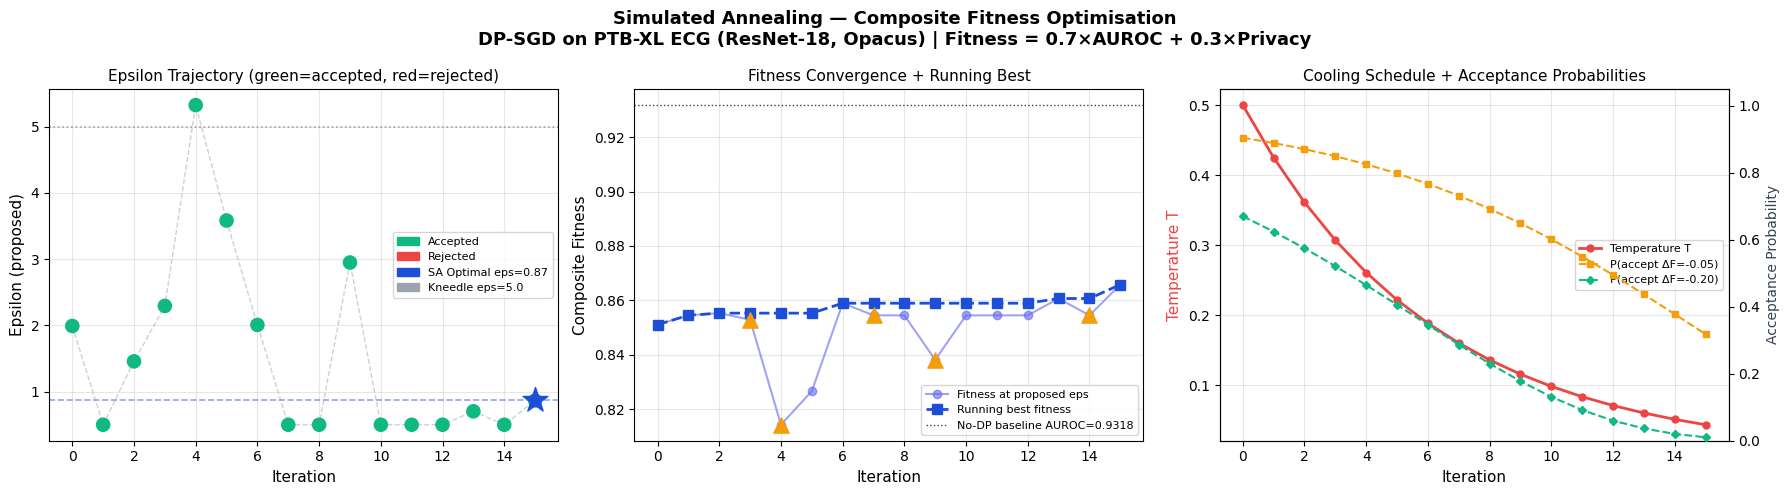

Plot saved to: /kaggle/working/sa_results/sa_results_plot.png


In [8]:
df_plot = pd.DataFrame(eval_log)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(
    'Simulated Annealing — Composite Fitness Optimisation\n'
    'DP-SGD on PTB-XL ECG (ResNet-18, Opacus) | Fitness = 0.7×AUROC + 0.3×Privacy',
    fontsize=13, fontweight='bold'
)

iters       = df_plot['iteration'].values
epsilons    = df_plot['epsilon'].values
fitnesses   = df_plot['fitness'].values
accepted    = df_plot['accepted'].values
aurocs      = df_plot['auroc'].values

colors_acc  = ['#10B981' if a else '#EF4444' for a in accepted]

# ─── Panel 1: Epsilon trajectory ─────────────────────────────────────────────
ax = axes[0]
ax.plot(iters, epsilons, 'o--', color='#9CA3AF', linewidth=1, markersize=4, zorder=3, alpha=0.5)
ax.scatter(iters, epsilons, c=colors_acc, s=90, zorder=5)

# Highlight best
ax.scatter([eval_log[list(epsilons).index(best_eps)]['iteration']],
           [best_eps], marker='*', color='#1D4ED8', s=350, zorder=6,
           label=f'SA Optimal eps={best_eps:.2f}')
ax.axhline(y=best_eps, color='#1D4ED8', linestyle='--', linewidth=1.2, alpha=0.5)
ax.axhline(y=KNEEDLE_EPS, color='#9CA3AF', linestyle=':', linewidth=1.2,
           label=f'Kneedle eps={KNEEDLE_EPS}')

green_patch = mpatches.Patch(color='#10B981', label='Accepted')
red_patch   = mpatches.Patch(color='#EF4444', label='Rejected')
ax.legend(handles=[green_patch, red_patch,
          mpatches.Patch(color='#1D4ED8', label=f'SA Optimal eps={best_eps:.2f}'),
          mpatches.Patch(color='#9CA3AF', label=f'Kneedle eps={KNEEDLE_EPS}')], fontsize=8)
ax.set_xlabel('Iteration', fontsize=11)
ax.set_ylabel('Epsilon (proposed)', fontsize=11)
ax.set_title('Epsilon Trajectory (green=accepted, red=rejected)', fontsize=11)
ax.grid(True, alpha=0.3)

# ─── Panel 2: Fitness over iterations ─────────────────────────────────────────
ax2 = axes[1]
running_best = [max(fitnesses[:i+1]) for i in range(len(fitnesses))]
ax2.plot(iters, fitnesses, 'o-', color='#6366F1', linewidth=1.5,
         markersize=6, alpha=0.6, label='Fitness at proposed eps', zorder=4)
ax2.plot(iters, running_best, 's--', color='#1D4ED8', linewidth=2,
         markersize=7, label='Running best fitness', zorder=5)
ax2.axhline(y=BASELINE_AUROC, color='#374151', linestyle=':', linewidth=1.0,
            label=f'No-DP baseline AUROC={BASELINE_AUROC:.4f}')

# Mark uphill accepted moves
for i, row in enumerate(eval_log):
    if i > 0 and row['accepted'] and row['fitness'] < fitnesses[i-1]:
        ax2.scatter([row['iteration']], [row['fitness']], marker='^',
                    color='#F59E0B', s=120, zorder=6)

ax2.set_xlabel('Iteration', fontsize=11)
ax2.set_ylabel('Composite Fitness', fontsize=11)
ax2.set_title('Fitness Convergence + Running Best', fontsize=11)
ax2.legend(fontsize=8)
ax2.grid(True, alpha=0.3)

# ─── Panel 3: Temperature cooling curve ──────────────────────────────────────
ax3 = axes[2]
all_iters = list(range(N_ITERATIONS + 1))
temps     = [T_START * (ALPHA ** i) for i in all_iters]
probs_neg005 = [math.exp(-0.05 / t) if t > 0 else 0 for t in temps]
probs_neg02  = [math.exp(-0.20 / t) if t > 0 else 0 for t in temps]

ax3.plot(all_iters, temps, 'o-', color='#EF4444', linewidth=2,
         markersize=5, label='Temperature T', zorder=5)
ax3b = ax3.twinx()
ax3b.plot(all_iters, probs_neg005, 's--', color='#F59E0B', linewidth=1.5,
          markersize=4, label='P(accept ΔF=-0.05)', zorder=4)
ax3b.plot(all_iters, probs_neg02, 'D--', color='#10B981', linewidth=1.5,
          markersize=4, label='P(accept ΔF=-0.20)', zorder=4)
ax3b.set_ylabel('Acceptance Probability', fontsize=10, color='#374151')
ax3b.set_ylim(0, 1.05)

ax3.set_xlabel('Iteration', fontsize=11)
ax3.set_ylabel('Temperature T', fontsize=11, color='#EF4444')
ax3.set_title('Cooling Schedule + Acceptance Probabilities', fontsize=11)

lines1, labels1 = ax3.get_legend_handles_labels()
lines2, labels2 = ax3b.get_legend_handles_labels()
ax3.legend(lines1 + lines2, labels1 + labels2, fontsize=8, loc='center right')
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plot_path = f'{RESULTS_DIR}/sa_results_plot.png'
plt.savefig(plot_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Plot saved to: {plot_path}")

## Cell 9 — Final Seven-Way Comparison

In [9]:
print("="*72)
print(" FINAL SEVEN-WAY COMPARISON — EPSILON OPTIMISATION METHODS")
print("="*72)
print(f"  {'Method':<35} | {'Optimal eps':>11} | {'AUROC':>8} | {'Fitness defined?':>16}")
print(f"  {'-'*35}-+-{'-'*11}-+-{'-'*8}-+-{'-'*16}")
print(f"  {'Kneedle (sweep baseline)':<35} | {KNEEDLE_EPS:>11.1f} | {KNEEDLE_AUROC:>8.4f} | {'No (grid)':>16}")
print(f"  {'Genetic Algorithm (composite)':<35} | {GA_EPS:>11.3f} | {GA_AUROC:>8.4f} | {'Yes (0.7/0.3)':>16}")
print(f"  {'Bayesian Optimisation (composite)':<35} | {BO_EPS:>11.4f} | {BO_AUROC:>8.4f} | {'Yes (0.7/0.3)':>16}")
print(f"  {'Particle Swarm (composite)':<35} | {PSO_EPS:>11.4f} | {PSO_AUROC:>8.4f} | {'Yes (0.7/0.3)':>16}")
print(f"  {'Simulated Annealing (composite)':<35} | {best_eps:>11.4f} | {best_auroc:>8.4f} | {'Yes (0.7/0.3)':>16}")
print(f"  {'NSGA-II (multi-objective)':<35} | {NSGA2_EPS:>11.4f} | {NSGA2_AUROC:>8.4f} | {'No (Pareto)':>16}")
print(f"  {'Epsilon-Constraint (eps<=1 tier)':<35} | {'1.0':>11} | {'0.8231':>8} | {'No (curve)':>16}")
print(f"  {'No-DP Baseline':<35} | {'inf':>11} | {BASELINE_AUROC:>8.4f} | {'-':>16}")
print("="*72)

# Agreement analysis
composite_eps = [GA_EPS, BO_EPS, PSO_EPS, best_eps]
composite_labels = ['GA', 'BO', 'PSO', 'SA']
print(f"\nComposite method agreement (all use 0.7/0.3 fitness):")
for lbl, e in zip(composite_labels, composite_eps):
    print(f"  {lbl:<4}: eps = {e:.4f}")
print(f"  Mean : {np.mean(composite_eps):.4f}")
print(f"  Std  : {np.std(composite_eps):.4f}")

print(f"\nSA-specific stats:")
print(f"  Uphill moves accepted (exploration): {n_uphill}")
print(f"  Total accepted moves               : {n_accepted}")
print(f"  Total rejected moves               : {n_rejected}")
print(f"  Acceptance rate                    : {n_accepted/(n_accepted+n_rejected)*100:.1f}%")

 FINAL SEVEN-WAY COMPARISON — EPSILON OPTIMISATION METHODS
  Method                              | Optimal eps |    AUROC | Fitness defined?
  ------------------------------------+-------------+----------+-----------------
  Kneedle (sweep baseline)            |         5.0 |   0.8777 |        No (grid)
  Genetic Algorithm (composite)       |       1.110 |   0.8698 |    Yes (0.7/0.3)
  Bayesian Optimisation (composite)   |      0.8056 |   0.8271 |    Yes (0.7/0.3)
  Particle Swarm (composite)          |      1.2035 |   0.8329 |    Yes (0.7/0.3)
  Simulated Annealing (composite)     |      0.8667 |   0.8269 |    Yes (0.7/0.3)
  NSGA-II (multi-objective)           |      8.9853 |   0.8548 |      No (Pareto)
  Epsilon-Constraint (eps<=1 tier)    |         1.0 |   0.8231 |       No (curve)
  No-DP Baseline                      |         inf |   0.9318 |                -

Composite method agreement (all use 0.7/0.3 fitness):
  GA  : eps = 1.1100
  BO  : eps = 0.8056
  PSO : eps = 1.2035
  S

---
## Appendix — How SA Compares to Other Methods

| Property | GA | BO (TPE) | PSO | **SA** |
|---|---|---|---|---|
| Paradigm | Evolutionary | Surrogate model | Swarm intelligence | **Probabilistic metaheuristic** |
| Population | Yes | No | Yes | **No (single solution)** |
| Accepts worse moves | No | Via EI acquisition | No | **Yes — exp(ΔF/T)** |
| Memory of history | Selection pressure | Full TPE model | Personal + global best | **Current solution only** |
| Escape mechanism | Mutation | Exploration bonus | Inertia overshoot | **Temperature-driven acceptance** |
| Key parameters | pop_size, crossover, mutation | n_trials | n_particles, w, c1, c2 | **T_start, alpha, sigma** |
| Reference | Holland (1975) | Bergstra et al. (2011) | Kennedy & Eberhart (1995) | **Kirkpatrick et al. (1983)** |

SA is the most memory-efficient method — it only needs to track the current solution and temperature. The uphill acceptance mechanism is what makes it fundamentally different from all other methods tested, and it directly mirrors the physical process of slow cooling that gave the algorithm its name.